# Combined LP Position Analysis

This notebook demonstrates **delta-neutral strategies** using two leveraged LP positions:

## Strategy Overview

1. **Position 1 (Long)**: Borrow USDC → Buy more ETH → Long ETH exposure
2. **Position 2 (Short)**: Borrow ETH → Sell ETH for USDC → Short ETH exposure

## Goal
By combining these positions with optimized:
- **Capital allocation** (how much in each position)
- **Leverage ratios** (2x, 3x, etc.)
- **Price ranges** (narrow vs wide)

We aim to create a **delta-neutral portfolio** that minimizes directional risk while earning LP fees.

## New Visualization
The `plot_combined_positions_dashboard()` method provides comprehensive analysis of two positions combined, showing:
- Combined PnL and returns
- Delta exposure (how well hedged)
- Gamma exposure (convexity)
- Asset holdings breakdown
- Key metrics comparison table


In [52]:
# Import the custom analysis module with forced reload
import importlib
import sys

# Remove all lp_analysis submodules from cache
modules_to_remove = [key for key in sys.modules.keys() if key.startswith('lp_analysis')]
for module in modules_to_remove:
    del sys.modules[module]

# Fresh import
from lp_analysis import (
    AssetPair, PriceRange, LPConfig,
    LPCalculator, LPAnalyzer, LPVisualizer
)

from lp_analysis import (
    AssetPair, PriceRange, LeveragedLPConfig, DebtAsset,
    LeveragedLPCalculator, LPAnalyzer, RiskAnalyzer, LPVisualizer,
    ExposureAnalyzer, ExposureVisualizer
)

print("Module reloaded with exposure analysis functionality!")
print(f"ExposureAnalyzer methods: {[m for m in dir(ExposureAnalyzer) if not m.startswith('_')]}")


Module reloaded with exposure analysis functionality!
ExposureAnalyzer methods: ['analyze_exposure', 'calculate_exposure_delta', 'calculate_exposure_profile', 'calculate_market_exposure', 'calculate_net_exposure', 'compare_exposure_strategies']


In [53]:
# Create two positions: one with USDC debt, one with ETH debt
config_usdc_debt1 = LeveragedLPConfig(
    capital_asset1=10000,
    price_initial=5000,
    price_range=PriceRange(4800, 5200),
    assets=AssetPair("ETH", "USDC"),
    leverage=2.0,
    debt_asset=DebtAsset.ASSET1,  # Borrow USDC → Long ETH
    borrow_apr=5.0,
)

config_usdc_debt2 = LeveragedLPConfig(
    capital_asset1=10000,
    price_initial=5000,
    price_range=PriceRange(4600, 5200),
    assets=AssetPair("ETH", "USDC"),
    leverage=2.0,
    debt_asset=DebtAsset.ASSET1,  # Borrow USDC → Long ETH
    borrow_apr=5.0,
)

config_eth_debt1 = LeveragedLPConfig(
    capital_asset1=10000,
    price_initial=5000,
    price_range=PriceRange(4800, 5200),
    assets=AssetPair("ETH", "USDC"),
    leverage=3.0,
    debt_asset=DebtAsset.ASSET0,  # Borrow ETH → Short ETH
    borrow_apr=5.0,
)

config_eth_debt2 = LeveragedLPConfig(
    capital_asset1=10000,
    price_initial=5000,
    price_range=PriceRange(4800, 5400),
    assets=AssetPair("ETH", "USDC"),
    leverage=3.0,
    debt_asset=DebtAsset.ASSET0,  # Borrow ETH → Short ETH
    borrow_apr=5.0,
)

/Users/mesfahani1/myProjects/project_defi_analyzer/lp_analysis/visualization/plots.py:208: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


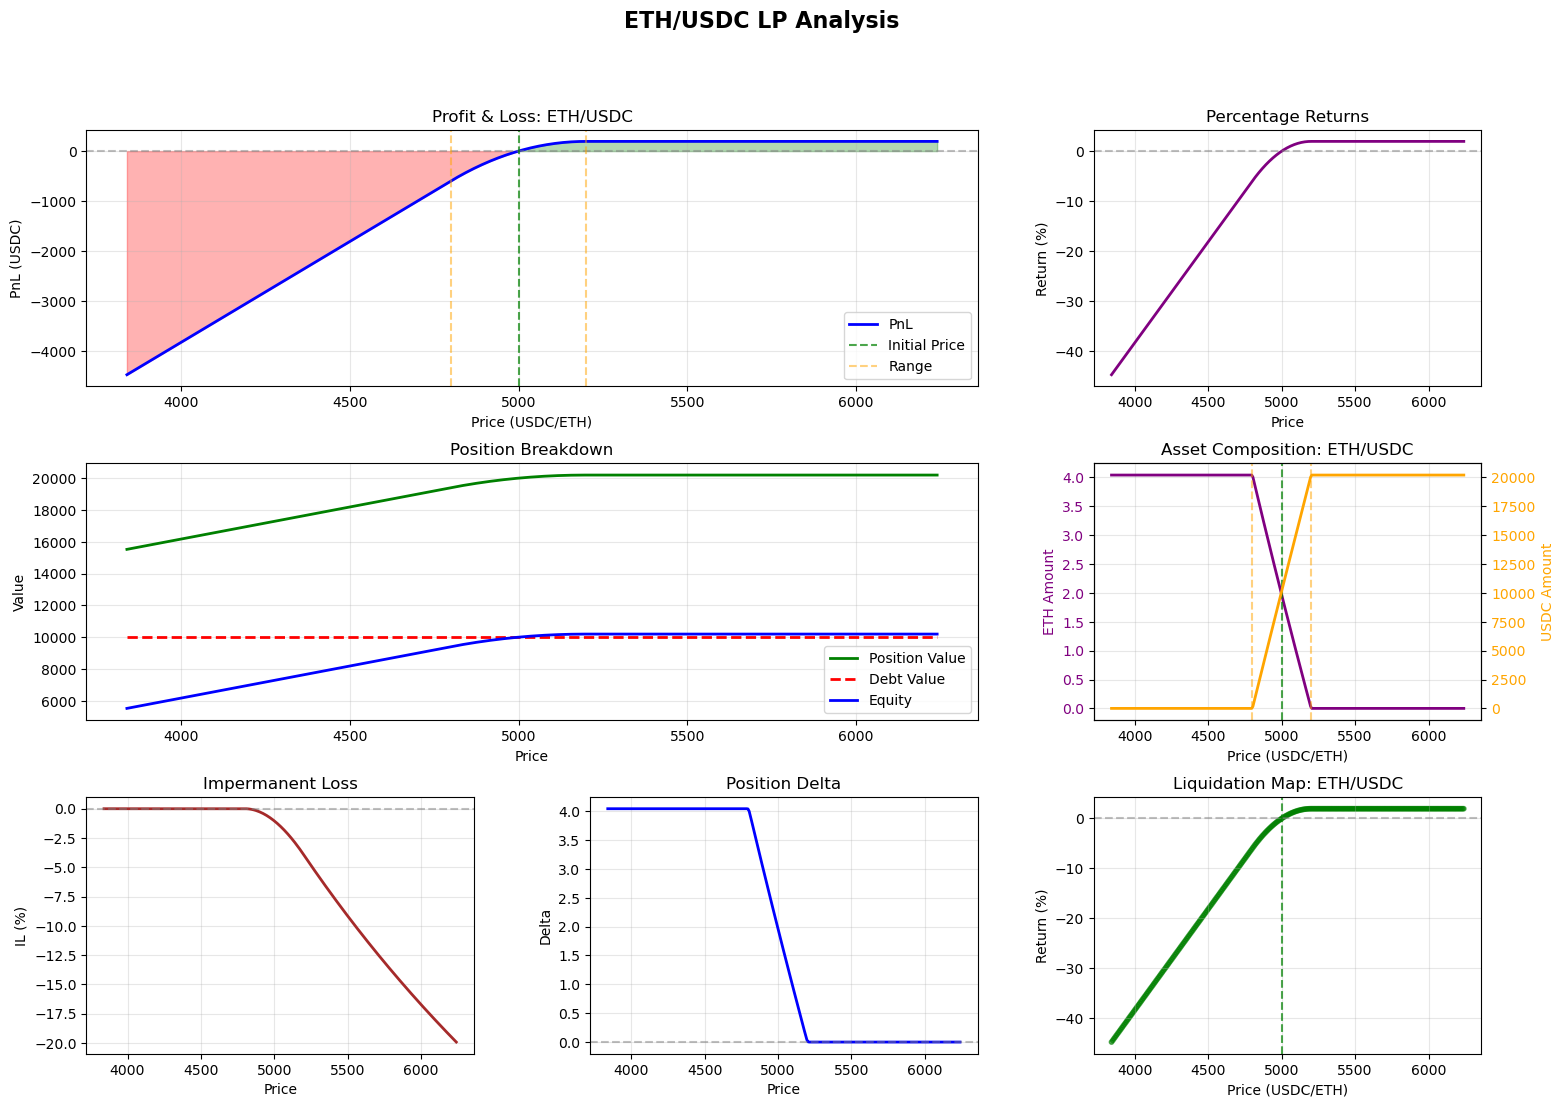

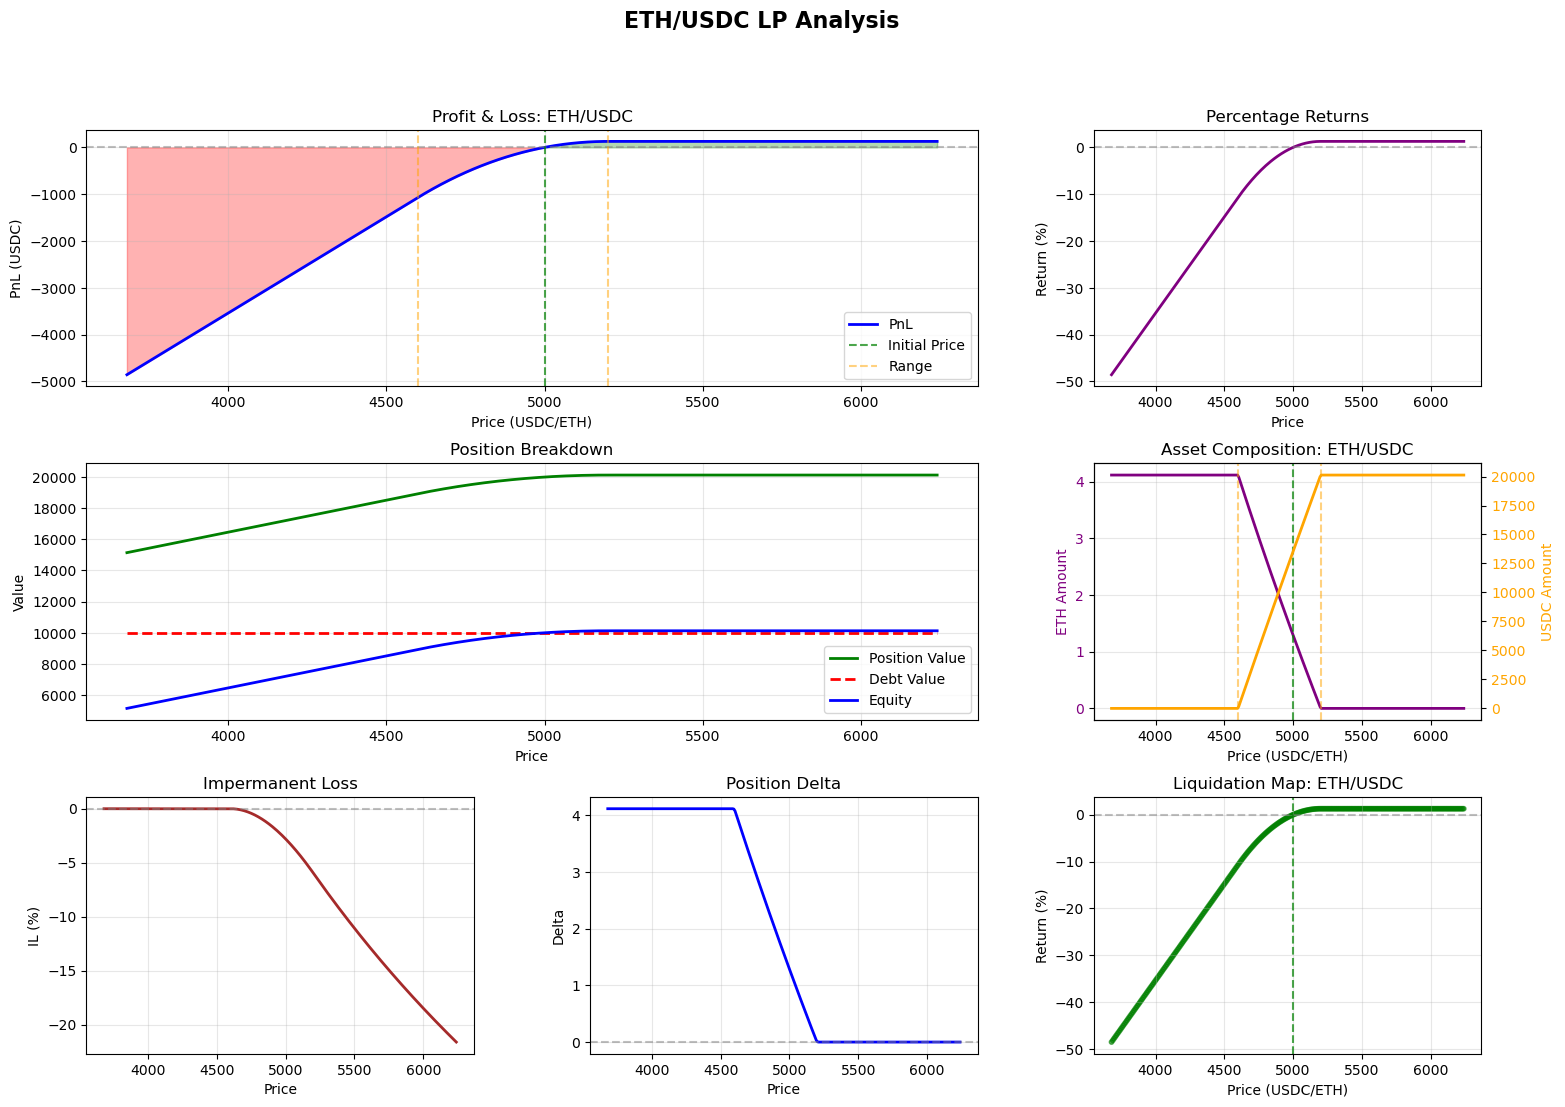

In [54]:
# Cell 3: Simulate
calc = LeveragedLPCalculator()
result_usdc1 = calc.simulate_price_range(config_usdc_debt1)
result_eth1 = calc.simulate_price_range(config_eth_debt1)

result_usdc2 = calc.simulate_price_range(config_usdc_debt2)
result_eth2 = calc.simulate_price_range(config_eth_debt2)

# Cell 4: Analyze
result_usdc1 = LPAnalyzer.analyze_simulation(result_usdc1)
result_usdc1.metrics['risk'] = RiskAnalyzer.analyze_risk(result_usdc1)
result_usdc1.metrics['exposure'] = ExposureAnalyzer.calculate_market_exposure(result_usdc1)

result_eth1 = LPAnalyzer.analyze_simulation(result_eth1)
result_eth1.metrics['risk'] = RiskAnalyzer.analyze_risk(result_eth1)
result_eth1.metrics['exposure'] = ExposureAnalyzer.calculate_market_exposure(result_eth1)

result_usdc2 = LPAnalyzer.analyze_simulation(result_usdc2)
result_usdc2.metrics['risk'] = RiskAnalyzer.analyze_risk(result_usdc2)
result_usdc2.metrics['exposure'] = ExposureAnalyzer.calculate_market_exposure(result_usdc2)

result_eth2 = LPAnalyzer.analyze_simulation(result_eth2)
result_eth2.metrics['risk'] = RiskAnalyzer.analyze_risk(result_eth2)
result_eth2.metrics['exposure'] = ExposureAnalyzer.calculate_market_exposure(result_eth2)

# Cell 6: Visualize
LPVisualizer.plot_comprehensive_dashboard(result_usdc1)
LPVisualizer.plot_comprehensive_dashboard(result_usdc2)



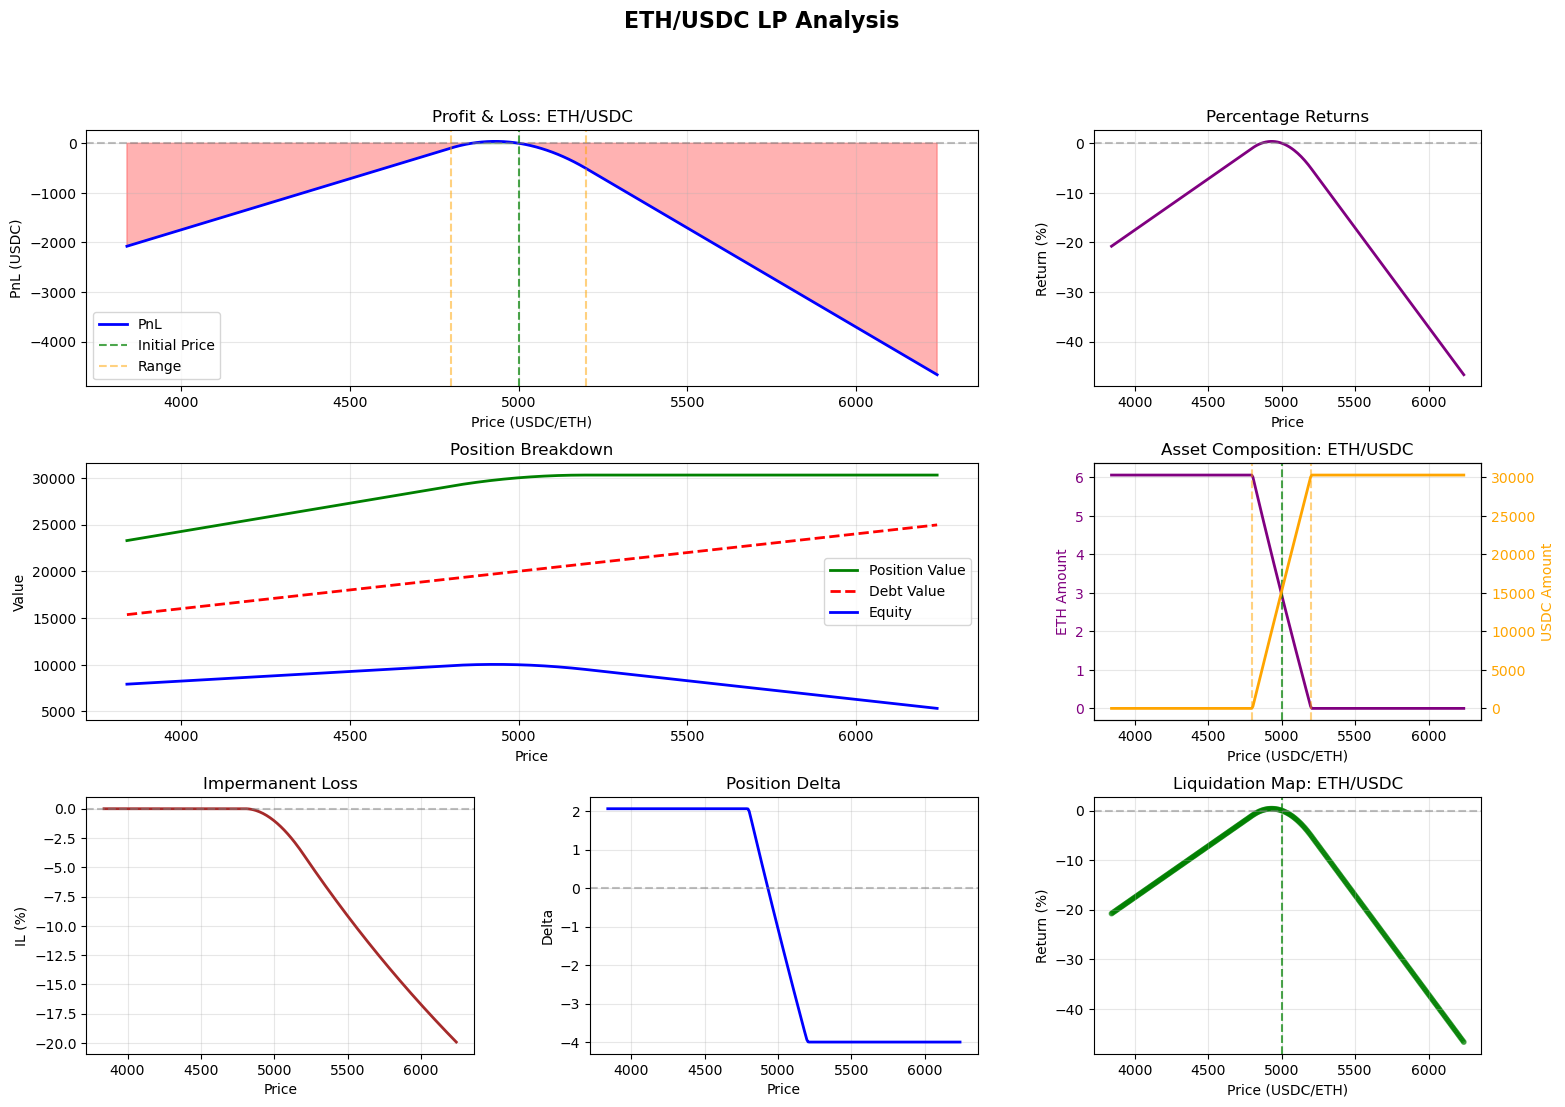

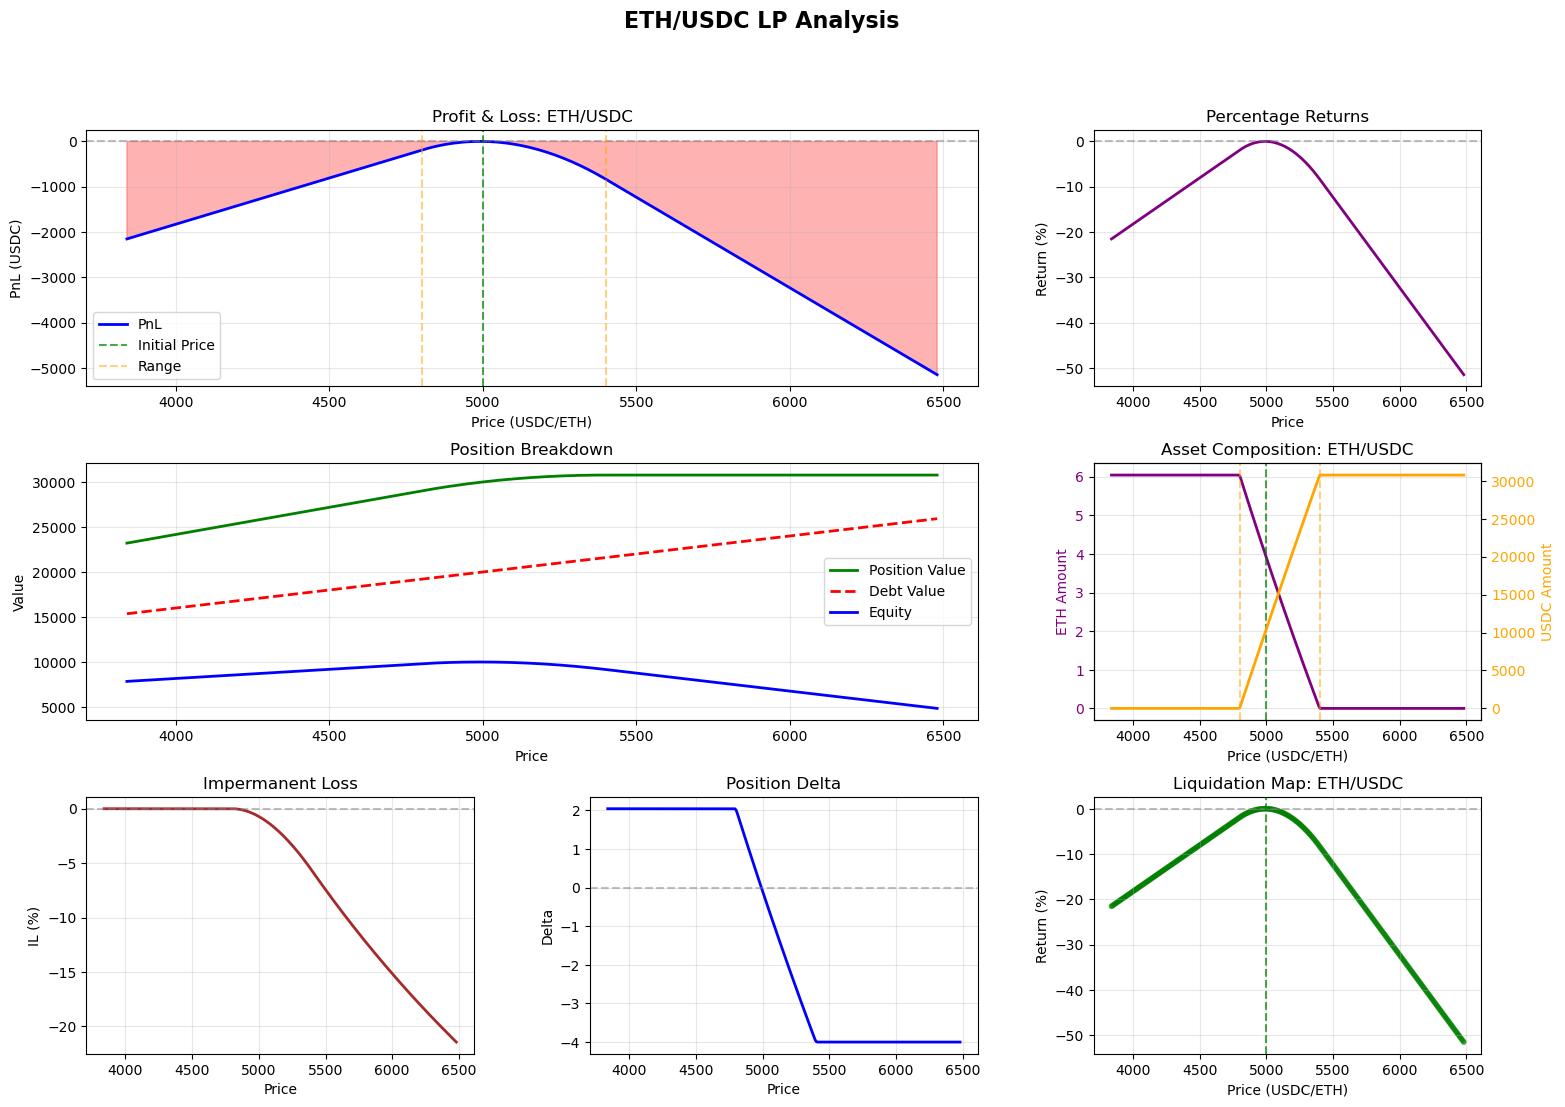

In [55]:
LPVisualizer.plot_comprehensive_dashboard(result_eth1)
LPVisualizer.plot_comprehensive_dashboard(result_eth2)

Combined Strategy 1: USDC Debt + ETH Debt (Same Range)


/Users/mesfahani1/myProjects/project_defi_analyzer/lp_analysis/visualization/plots.py:531: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


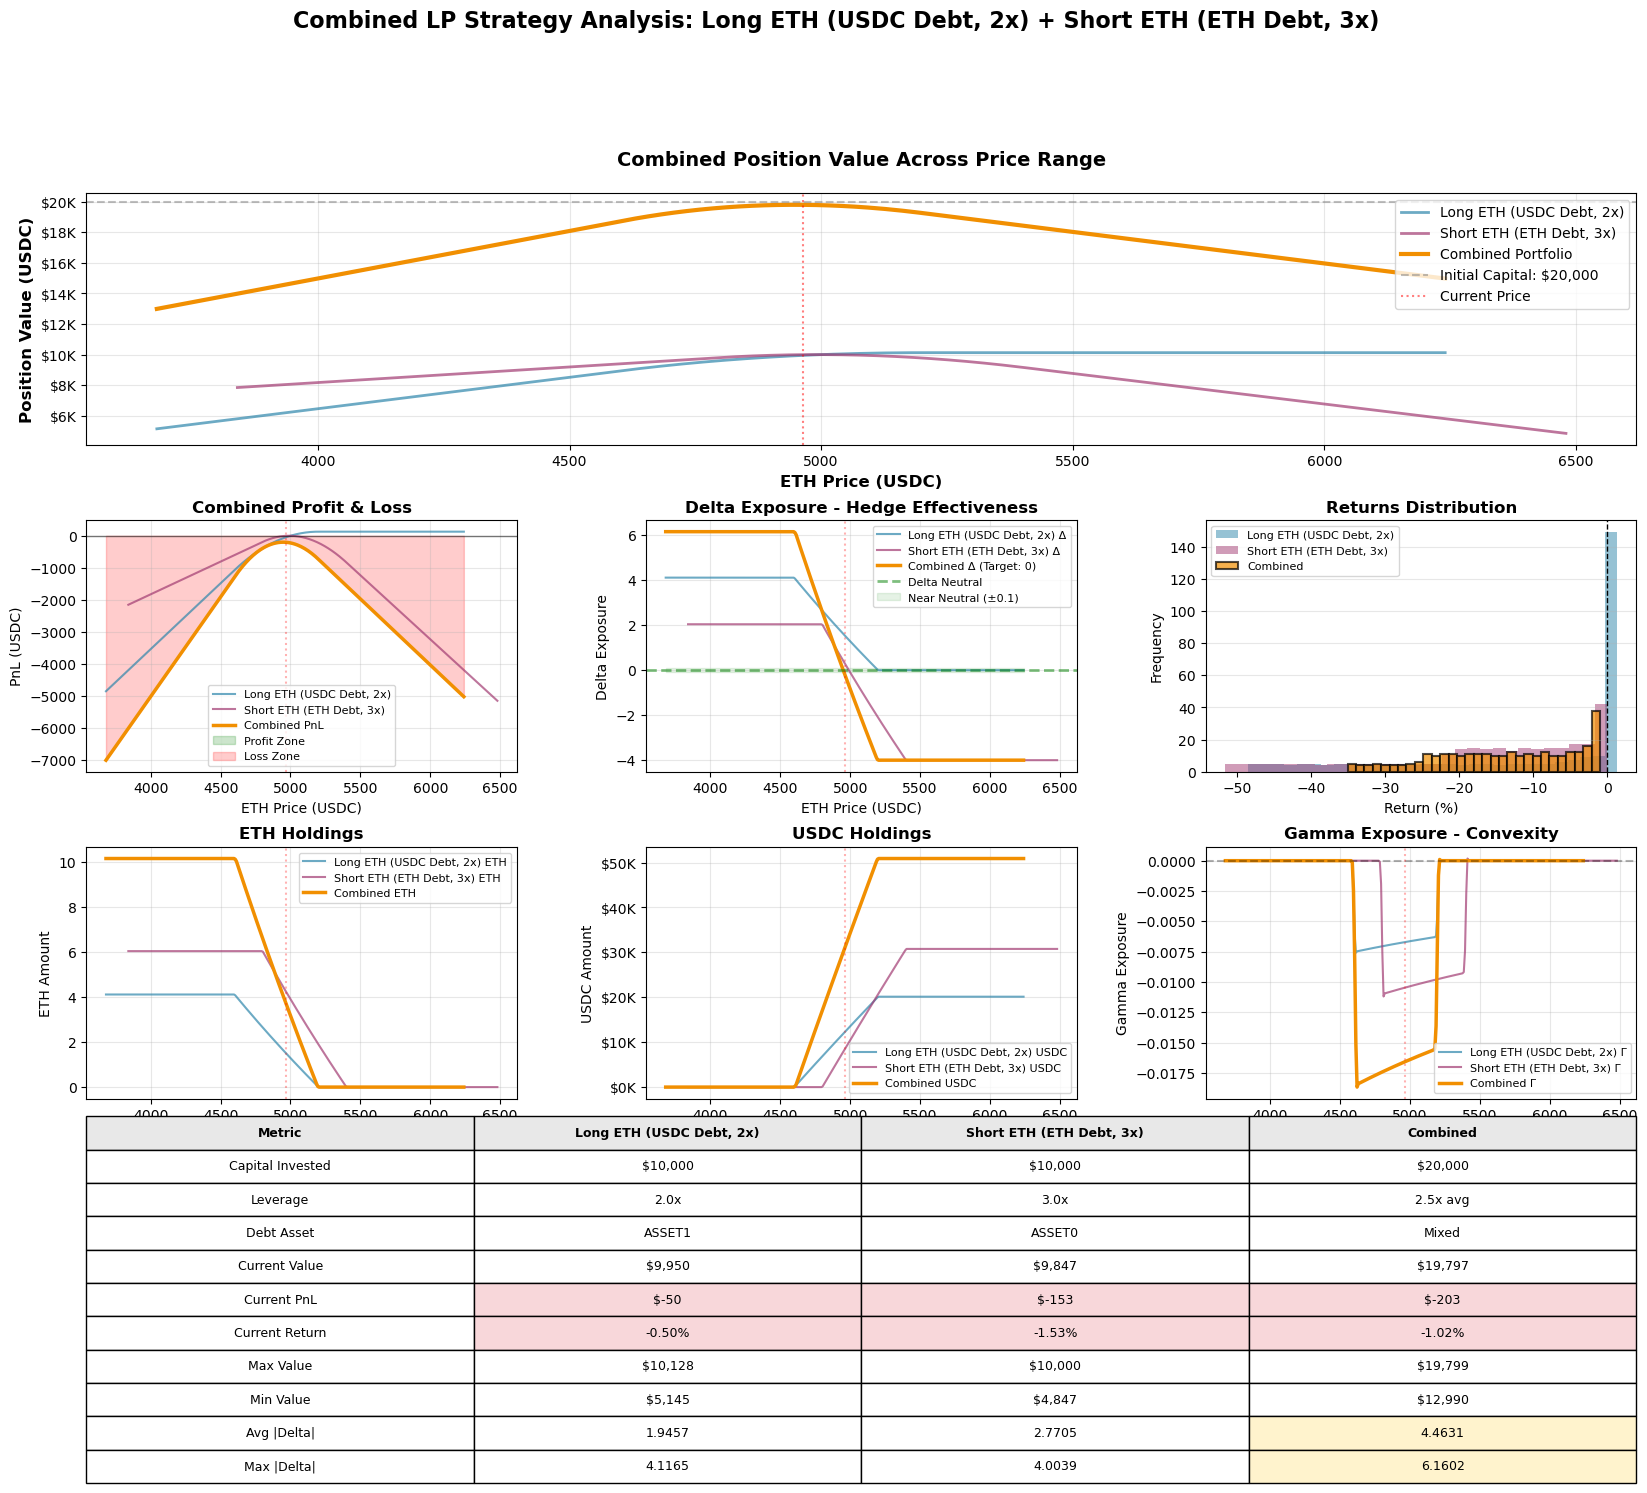


COMBINED POSITION SUMMARY

Positions:
  • Long ETH (USDC Debt, 2x): $10,000 @ 2.0x (ASSET1 debt)
  • Short ETH (ETH Debt, 3x): $10,000 @ 3.0x (ASSET0 debt)

Combined Portfolio:
  Total Capital: $20,000
  Current Value: $19,797
  Current PnL: $-203 (-1.02%)

Delta Neutrality:
  Average |Δ|: 4.4631
  Maximum |Δ|: 6.1602
  Assessment: ✗ Poorly Hedged



In [57]:
# Visualize combined positions
print("Combined Strategy 1: USDC Debt + ETH Debt (Same Range)")
LPVisualizer.plot_combined_positions_dashboard(
    result_usdc2, 
    result_eth2,
    position1_name="Long ETH (USDC Debt, 2x)",
    position2_name="Short ETH (ETH Debt, 3x)"
)

